In [ ]:
import os
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42

# File Paths
BASE_DIR = os.getcwd()
DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "Student_Performance_cleaned.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODEL_OUTPUT_DIR = os.path.join(RESULTS_DIR, "model_outputs", "trained_models")
METRICS_DIR = os.path.join(RESULTS_DIR, "metrics")

In [ ]:
df = pd.read_csv(DATA_PATH)
FEATURES = ["Hours Studied", "Previous Scores", "Extracurricular Activities",
            "Sleep Hours", "Sample Question Papers Practiced", "StudyEfficiency"]
TARGET = "Performance Index"

X = df[FEATURES]
y = df[TARGET]

In [ ]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [ ]:
# Feature Scaling

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [ ]:
# Evaluation Function

def evaluate(y_true, y_pred, name="Model"):
    """Calculate MAE, RMSE, and R2 for a model and print."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} --> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")
    return mae, rmse, r2

In [ ]:
# Define Models

models_info = {
    "IT24103506_MLR": {"model": LinearRegression(), "scaled": True},
    "IT24103519_RF": {"model": RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300, max_depth=12, max_features='sqrt'), "scaled": False},
    "IT24103558_SVR": {"model": SVR(C=100, gamma=0.1, kernel='rbf'), "scaled": True},
    "IT24103553_GBR": {"model": GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE), "scaled": False},
    "IT24102613_DTR": {"model": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE), "scaled": False},
    "IT24103609_MLP": {"model": MLPRegressor(hidden_layer_sizes=(100,50), max_iter=500, activation='relu', random_state=RANDOM_STATE), "scaled": True},
}

In [ ]:
# Train, Evaluate, Save Models

results_list = []

for name, info in models_info.items():
    model = info["model"]
    X_train_input = X_train_scaled if info["scaled"] else X_train
    X_test_input = X_test_scaled if info["scaled"] else X_test
    
    # Train model
    model.fit(X_train_input, y_train)
    
    # Save trained model
    model_file = os.path.join(MODEL_OUTPUT_DIR, f"{name}_best_model.pkl")
    joblib.dump(model, model_file)
    
    # Predict and evaluate
    y_pred = model.predict(X_test_input)
    mae, rmse, r2 = evaluate(y_test, y_pred, name)
    
    # Save results
    results_list.append({
        "Member": name.split("_")[0],
        "Model": name.split("_")[1],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Model_File": model_file
    })
    
    # Save metadata
    metadata_file = os.path.join(MODEL_OUTPUT_DIR, f"{name}_metadata.json")
    metadata = {
        "member_id": name.split("_")[0],
        "model_name": name.split("_")[1],
        "scaled": info["scaled"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }
    with open(metadata_file, "w") as f:
        json.dump(metadata, f, indent=4)

IT24103506_MLR --> MAE: 1.647, RMSE: 2.075, R2: 0.988
IT24103519_RF --> MAE: 1.951, RMSE: 2.434, R2: 0.984
IT24103558_SVR --> MAE: 1.681, RMSE: 2.122, R2: 0.988
IT24103553_GBR --> MAE: 1.703, RMSE: 2.142, R2: 0.988
IT24102613_DTR --> MAE: 2.043, RMSE: 2.576, R2: 0.982
IT24103609_MLP --> MAE: 1.671, RMSE: 2.102, R2: 0.988


In [ ]:
# Create Results DataFrame

results_df = pd.DataFrame(results_list).sort_values(by="R2", ascending=False).reset_index(drop=True)
results_csv = os.path.join(METRICS_DIR, "group_results.csv")
results_df.to_csv(results_csv, index=False)
display(results_df)

,Member,Model,MAE,RMSE,R2,Model_File
0,IT24103506,MLR,1.646589,2.075276,0.988428,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...
1,IT24103609,MLP,1.670672,2.102411,0.988123,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...
2,IT24103558,SVR,1.680522,2.122014,0.987901,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...
3,IT24103553,GBR,1.703361,2.141791,0.987674,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...
4,IT24103519,RF,1.951099,2.434481,0.984075,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...
5,IT24102613,DTR,2.043482,2.575525,0.982176,C:\Users\vimuk\Documents\Y2S1\AIML\2025-Y2-S1-...


In [ ]:
# Select Final Model

final_model_row = results_df[results_df["Model"] == "MLR"].iloc[0]
final_model_name = final_model_row["Model"]
final_member = final_model_row["Member"]
print(f"\nSelected Final Model: {final_model_name} by Member {final_member}")

# (MLR = Multiple Linear Regression)


Selected Final Model: MLR by Member IT24103506


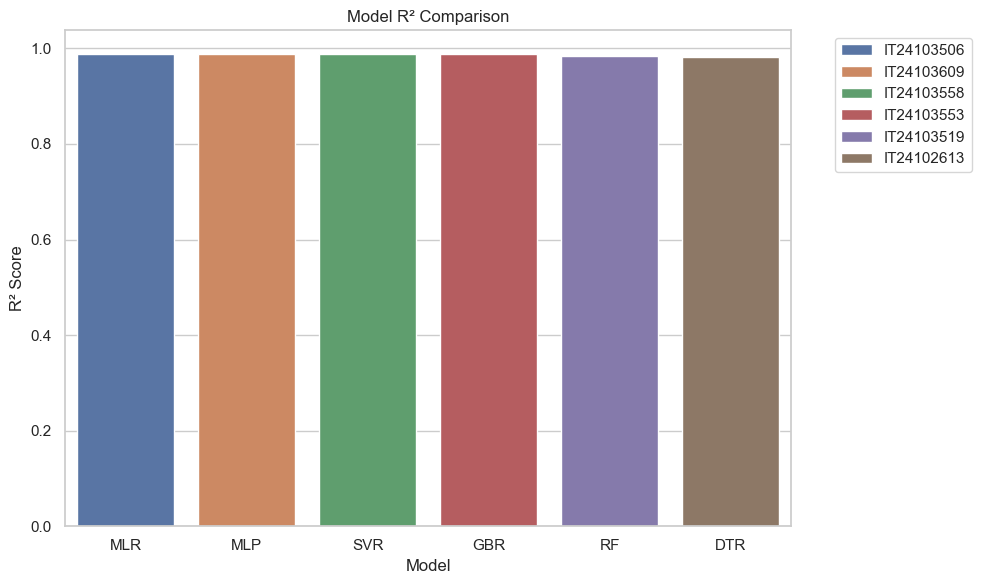

In [ ]:
# Visualization: R^2 Comparison

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.barplot(x="Model", y="R2", hue="Member", data=results_df)
plt.title("Model R² Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

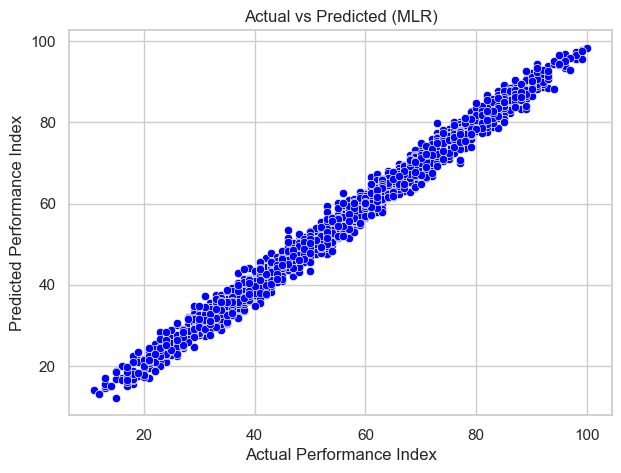

In [ ]:
# Visualization: Actual vs Predicted (Final Model)

final_model_file = final_model_row["Model_File"]
final_model = joblib.load(final_model_file)

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=final_model.predict(X_test_scaled if models_info["IT24103506_MLR"]["scaled"] else X_test), color='blue')
plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title(f"Actual vs Predicted ({final_model_name})")
plt.grid(True)
plt.show()

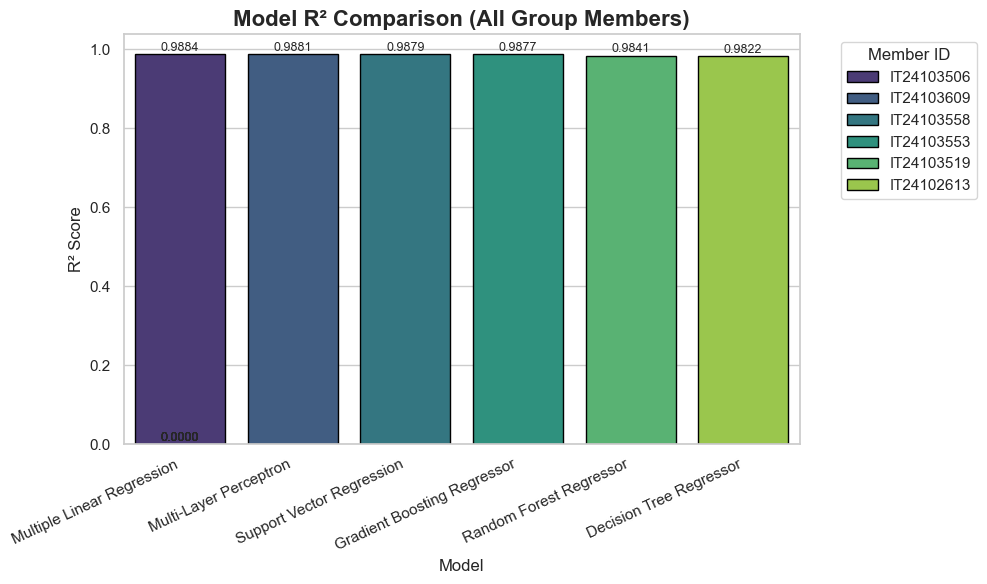

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Member': [
        'IT24103506', 'IT24103609', 'IT24103558',
        'IT24103553', 'IT24103519', 'IT24102613'
    ],
    'Model': [
        'Multiple Linear Regression', 'Multi-Layer Perceptron', 'Support Vector Regression',
        'Gradient Boosting Regressor', 'Random Forest Regressor', 'Decision Tree Regressor'
    ],
    'R2': [0.988428, 0.988123, 0.987901, 0.987674, 0.984075, 0.982176]
}

results_df = pd.DataFrame(data)

# --- Highlight Best Model (Highest R²) ---
best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']

# Set style
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

# Create color palette
colors = ['gold' if m == best_model else 'skyblue' for m in results_df['Model']]

# Create barplot
ax = sns.barplot(
    x="Model",
    y="R2",
    hue="Member",
    data=results_df,
    palette="viridis",
    dodge=False,  # Combine bars by model
    edgecolor="black"
)

# Add value labels
for p in ax.patches:
    ax.text(
        p.get_x() + p.get_width() / 2,
        p.get_height() + 0.0005,
        f"{p.get_height():.4f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Titles and labels
plt.title("Model R² Comparison (All Group Members)", fontsize=16, fontweight='bold')
plt.ylabel("R² Score", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.xticks(rotation=25, ha="right")

# Adjust legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Member ID")

plt.tight_layout()
plt.show()